In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(
    0,
    str(PROJECT_ROOT),
)

from src.risk.dashboard_metrics import (
    build_dashboard_metrics,
)

metrics = (
    build_dashboard_metrics()
)

metrics

{'var_99': 86818.89692916145,
 'es_99': 128987.72894019056,
 'worst_daily_pnl': -237048.6794262268,
 'worst_stress_pnl': -493906.4767859965,
 'breaches': 2,
 'warnings': 2}

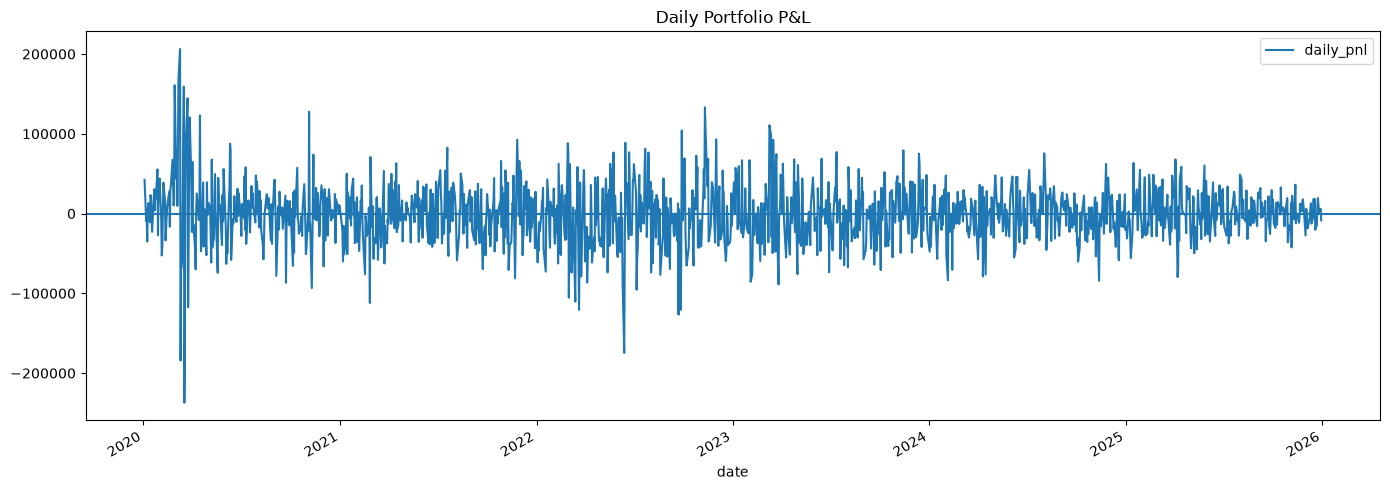

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

daily_pnl = pd.read_csv(
    PROJECT_ROOT
    / "reports"
    / "daily_pnl.csv",
    parse_dates=["date"],
)

daily_pnl.plot(
    x="date",
    y="daily_pnl",
    figsize=(14, 5),
    title="Daily Portfolio P&L",
)

plt.axhline(0)
plt.tight_layout()
plt.show()

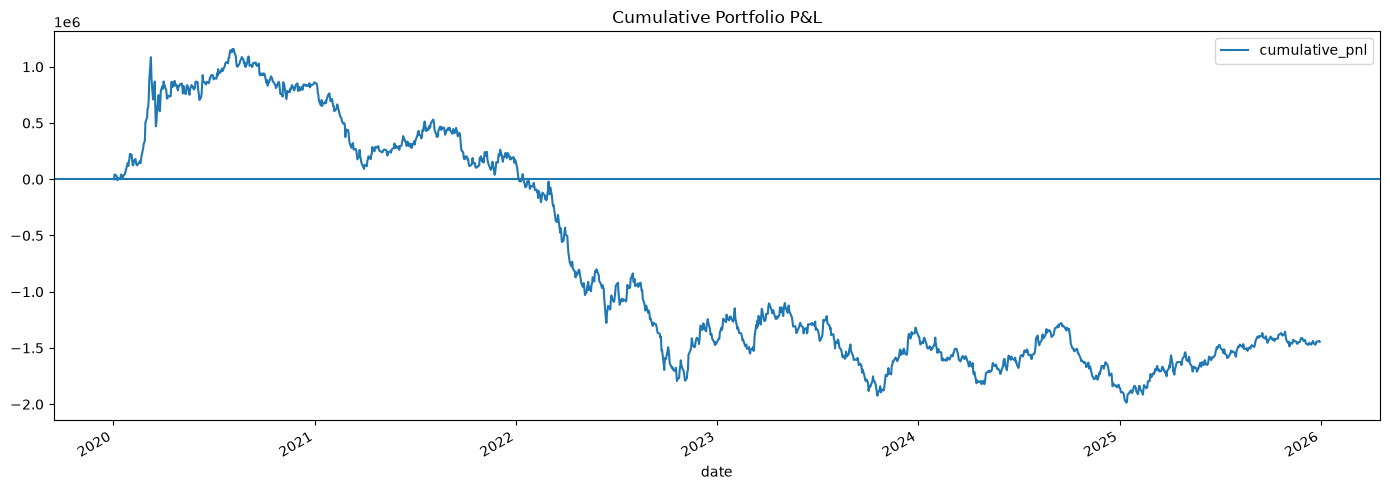

In [3]:
daily_pnl[
    "cumulative_pnl"
] = daily_pnl[
    "daily_pnl"
].fillna(0).cumsum()

daily_pnl.plot(
    x="date",
    y="cumulative_pnl",
    figsize=(14, 5),
    title="Cumulative Portfolio P&L",
)

plt.axhline(0)
plt.tight_layout()
plt.show()

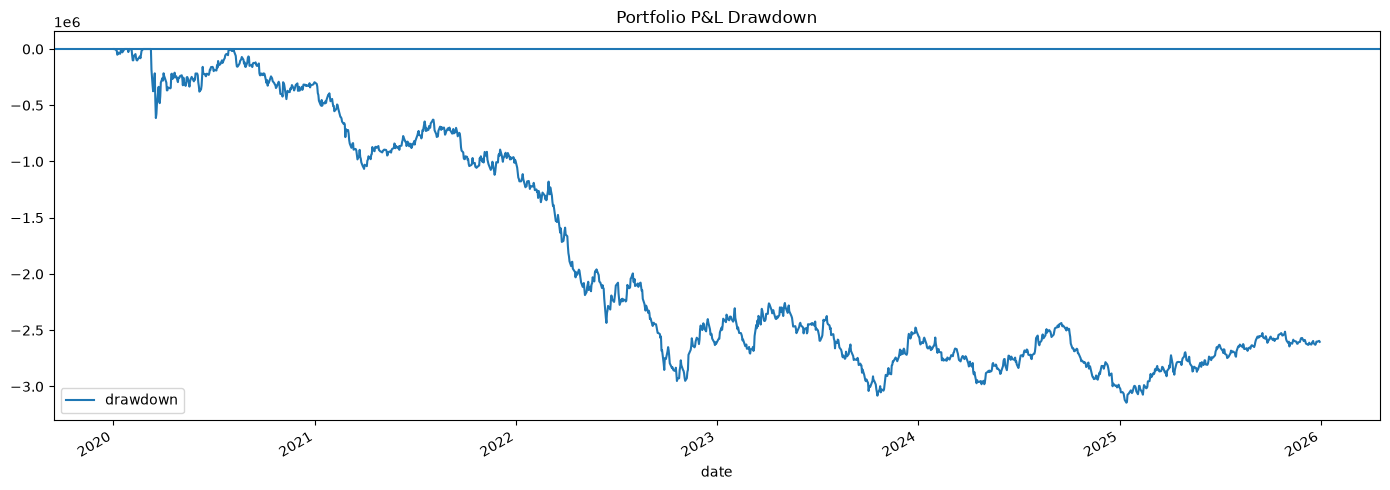

In [4]:
daily_pnl[
    "running_max"
] = daily_pnl[
    "cumulative_pnl"
].cummax()

daily_pnl[
    "drawdown"
] = (
    daily_pnl["cumulative_pnl"]
    - daily_pnl["running_max"]
)

daily_pnl.plot(
    x="date",
    y="drawdown",
    figsize=(14, 5),
    title="Portfolio P&L Drawdown",
)

plt.axhline(0)
plt.tight_layout()
plt.show()

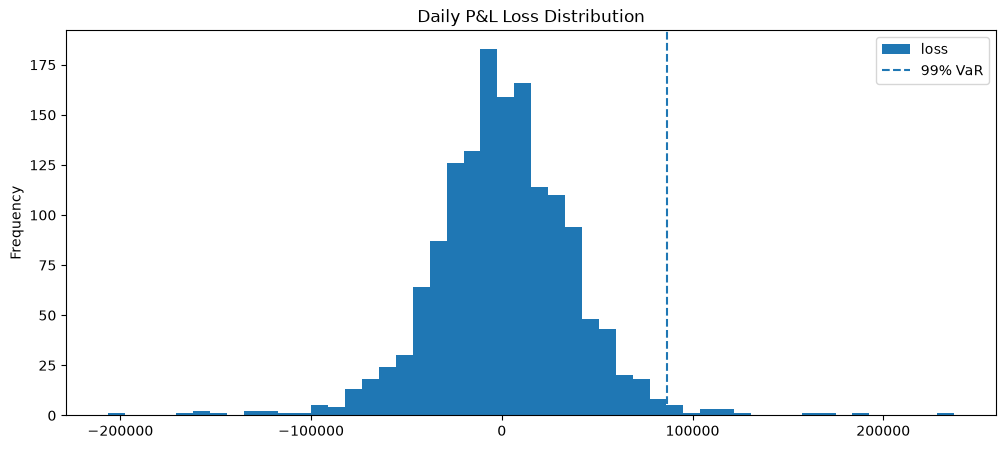

In [5]:
var_99 = metrics["var_99"]

daily_pnl["loss"] = (
    -daily_pnl["daily_pnl"]
)

daily_pnl["loss"].plot(
    kind="hist",
    bins=50,
    figsize=(12, 5),
    title="Daily P&L Loss Distribution",
)

plt.axvline(
    var_99,
    linestyle="--",
    label="99% VaR",
)

plt.legend()
plt.show()

In [6]:
from src.risk.stress_testing import run_stress_scenarios

stress_results = run_stress_scenarios()

stress_results

,scenario,description,base_portfolio_value,stress_pnl,stressed_value
0,Equity Down 10%,Broad equity market decline,5.482227e+06,-29439.758644,5.452788e+06
1,Equity Crash + Volatility Spike,Equity selloff accompanied by volatility increase,5.482227e+06,-44298.773656,5.437929e+06
2,Rates Up 100bp,Parallel upward rate shock,5.482227e+06,-434787.922852,5.047439e+06
3,Rates Down 100bp,Parallel downward rate shock,5.482227e+06,434787.922852,5.917015e+06
4,Combined Market Shock,"Equity decline, volatility increase and rates ...",5.482227e+06,-493906.476786,4.988321e+06


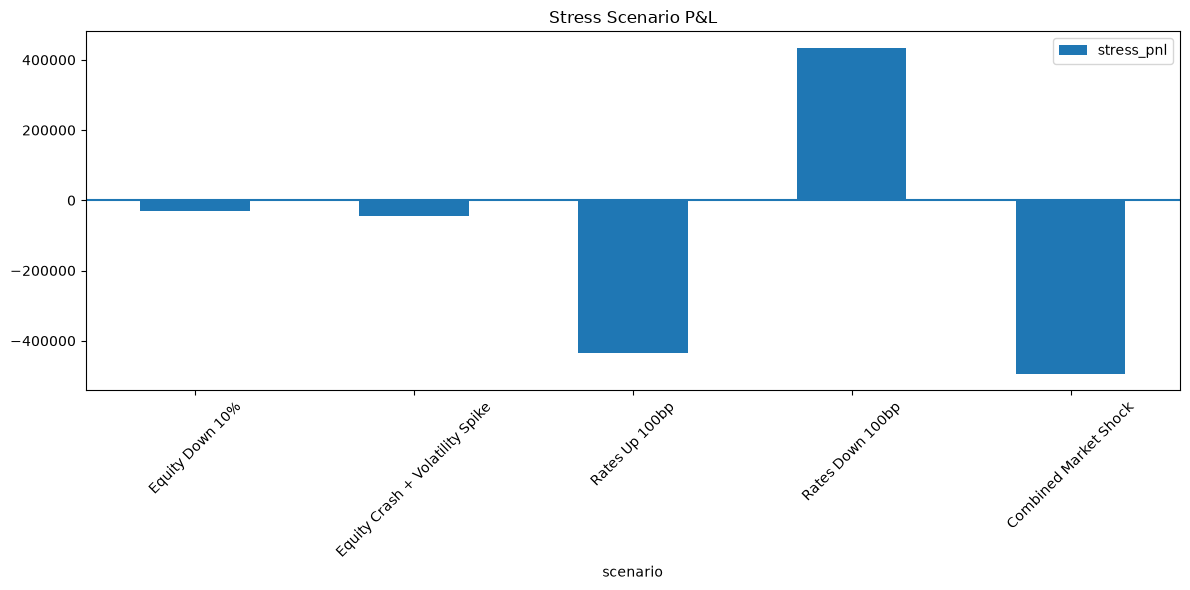

In [7]:
stress_results.plot(
    x="scenario",
    y="stress_pnl",
    kind="bar",
    figsize=(12, 6),
    title="Stress Scenario P&L",
)

plt.xticks(rotation=45)
plt.axhline(0)
plt.tight_layout()
plt.show()

In [8]:
summary = pd.DataFrame(
    {
        "Metric": [
            "VaR 99%",
            "Expected Shortfall 99%",
            "Worst Daily P&L",
            "Worst Stress P&L",
            "Limit Breaches",
            "Limit Warnings",
        ],
        "Value": [
            metrics["var_99"],
            metrics["es_99"],
            metrics["worst_daily_pnl"],
            metrics["worst_stress_pnl"],
            metrics["breaches"],
            metrics["warnings"],
        ],
    }
)

summary

,Metric,Value
0,VaR 99%,86818.896929
1,Expected Shortfall 99%,128987.728940
2,Worst Daily P&L,-237048.679426
3,Worst Stress P&L,-493906.476786
4,Limit Breaches,2.000000
5,Limit Warnings,2.000000


In [9]:
from src.risk.risk_commentary import (
    generate_commentary,
)

commentary = generate_commentary(
    var_99=metrics["var_99"],
    es_99=metrics["es_99"],
    worst_daily_pnl=metrics[
        "worst_daily_pnl"
    ],
    worst_stress_pnl=metrics[
        "worst_stress_pnl"
    ],
    breaches=metrics["breaches"],
    warnings=metrics["warnings"],
)

print(commentary)

99% historical VaR is 86,818.90. 99% Expected Shortfall is 128,987.73. The worst observed daily P&L was -237,048.68. The worst configured stress scenario produced P&L of -493,906.48. There are 2 active risk-limit breaches requiring attention.


In [10]:
commentary_file = (
    PROJECT_ROOT
    / "reports"
    / "risk_commentary.txt"
)

commentary_file.write_text(
    commentary,
    encoding="utf-8",
)

242

In [11]:
import pandas as pd
risk_report = pd.read_csv(
    "../reports/portfolio_risk_report.csv"
)
risk_report

,valuation_date,trade_id,instrument_type,underlying,quantity,spot,rate,market_value,delta,gamma,vega,rho,theta,ir_dv01
0,2025-12-30,EQ001,EQUITY,AAPL,1000,272.338684,0.0414,2.723387e+05,1.000000e+03,0.000000,0.000000,0.000000,0.000000,0.000000
1,2025-12-30,EQ002,EQUITY,SPY,-500,683.378357,0.0414,-3.416892e+05,-5.000000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
2,2025-12-30,EQ003,EQUITY,MSFT,750,485.318756,0.0414,3.639891e+05,7.500000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
3,2025-12-30,OPT001,EUROPEAN_CALL,AAPL,20,272.338684,0.0414,1.349520e+03,1.669841e+01,0.060527,1302.472056,3092.958349,-311.675599,0.000000
4,2025-12-30,OPT002,EUROPEAN_PUT,AAPL,-15,272.338684,0.0414,-6.031344e+01,1.411328e+00,-0.031291,-673.345060,430.053211,87.947597,0.000000
5,2025-12-30,OPT003,EUROPEAN_CALL,SPY,-10,683.378357,0.0414,-1.135952e+03,-8.076977e+00,-0.019489,-1760.485804,-4239.558027,297.281970,0.000000
6,2025-12-30,BND001,BOND,US10Y,5000000,4.140000,0.0414,4.938648e+06,0.000000e+00,0.000000,0.000000,0.000000,0.000000,4347.879229
7,2025-12-30,FX001,FX_FORWARD,EURUSD,2000000,1.177288,0.0414,2.487870e+05,2.000000e+06,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
from src.risk.dashboard_metrics import (
    build_dashboard_metrics,
)

metrics = build_dashboard_metrics()

metrics

{'var_99': 86818.89692916145,
 'es_99': 128987.72894019056,
 'worst_daily_pnl': -237048.6794262268,
 'worst_stress_pnl': -493906.4767859965,
 'breaches': 2,
 'warnings': 2}

In [13]:
from src.risk.risk_commentary import (
    generate_commentary,
)

commentary = generate_commentary(
    var_99=metrics["var_99"],
    es_99=metrics["es_99"],
    worst_daily_pnl=metrics[
        "worst_daily_pnl"
    ],
    worst_stress_pnl=metrics[
        "worst_stress_pnl"
    ],
    breaches=metrics[
        "breaches"
    ],
    warnings=metrics[
        "warnings"
    ],
)

print(commentary)

99% historical VaR is 86,818.90. 99% Expected Shortfall is 128,987.73. The worst observed daily P&L was -237,048.68. The worst configured stress scenario produced P&L of -493,906.48. There are 2 active risk-limit breaches requiring attention.


In [14]:
with open(
    "../reports/risk_commentary.txt",
    "w",
    encoding="utf-8",
) as file:

    file.write(commentary)

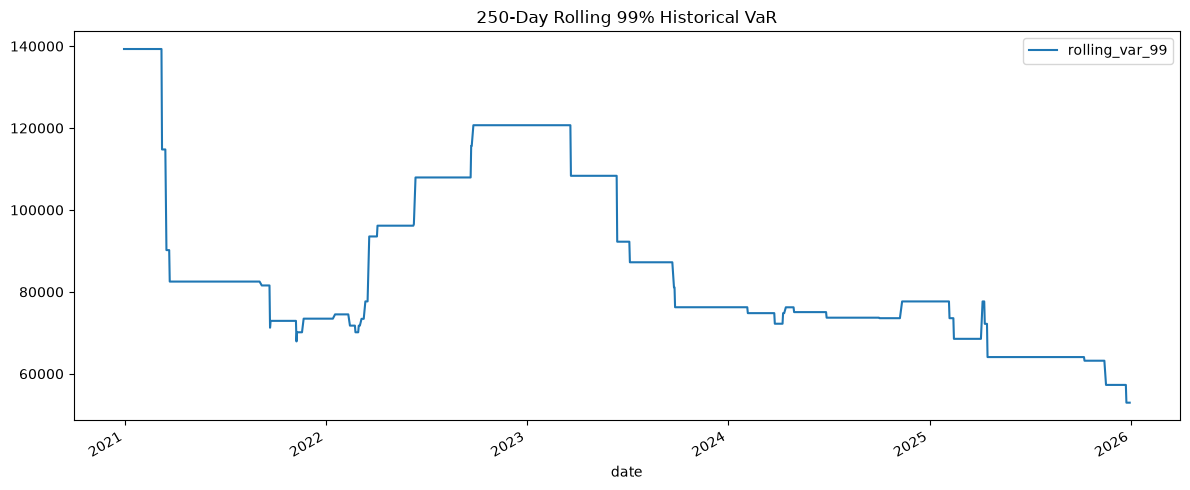

In [16]:
daily_pnl.plot(
    x="date",
    y="rolling_var_99",
    figsize=(12, 5),
    title="250-Day Rolling 99% Historical VaR",
)

plt.tight_layout()

plt.show()